In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/My Drive/Colab Notebooks/projet8/dev
!pwd
!ls -l

/content/drive/My Drive/Colab Notebooks/projet8/dev
/content/drive/My Drive/Colab Notebooks/projet8/dev
total 1400321
-rw------- 1 root root 97899091 Jan 19 07:08  best_segmentation_model.pth
-rw------- 1 root root      710 Feb 26 09:53  Dockerfile
drwx------ 2 root root     4096 Feb 20 10:41  heroku-fastapi
drwx------ 2 root root     4096 Feb 26 15:32  heroku-streamlit
drwx------ 2 root root     4096 Feb 20 10:41  heroku-train
-rw------- 1 root root 57406731 Mar 13 09:07  model_reference_unet_mini.pth
-rw------- 1 root root 57406731 Mar 13 08:09  model_reference_unet_mini.pth.backup
-rw------- 1 root root 97905487 Mar 13 10:28  mon_meilleur_modele_segmentation.pth
-rw------- 1 root root  1438494 Mar  6 15:27  p8_1_prepare_image.ipynb
-rw------- 1 root root 19011515 Mar 13 13:32 'p8_2_train_it copy.ipynb'
-rw------- 1 root root 20514860 Mar 14 12:06  p8_2_train_it.ipynb
-rw------- 1 root root  5163805 Jan 16 08:58  p8_2_train_it_sandbox.ipynb
-rw------- 1 root root  2716476 Mar 14 14:0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Outils prêts ! On va pouvoir simplifier notre monde.
✅ Outils prêts ! On va pouvoir simplifier notre monde.
Chemin des images pour l'analyse : /content/drive/My Drive/Colab Notebooks/projet8/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit
Chemin des masques pour l'analyse : /content/drive/My Drive/Colab Notebooks/projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine

Chargement des résultats EDA depuis le cache : /content/drive/My Drive/Colab Notebooks/projet8/eda_cache.joblib
✅ Résultats EDA chargés depuis le cache.

--- RÉSULTATS DE L'ANALYSE EXPLORATOIRE ---

--- IMAGES ORIGINALES ---
Nombre total d'images analysées : 3475
Dimensions (min/max/moyenne) : 2048x1024 / 2048x1024 / 2048.00x1024.00
Formats trouvés : {'PNG'}
Nombre de canaux trouvés : {3}

--- MASQUES (gtFine_labelIds) ---
Nombre total de masques analysés : 3475
Dimensions (min/max/moye

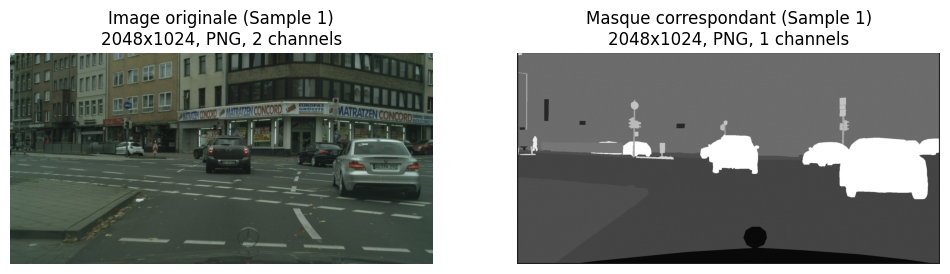

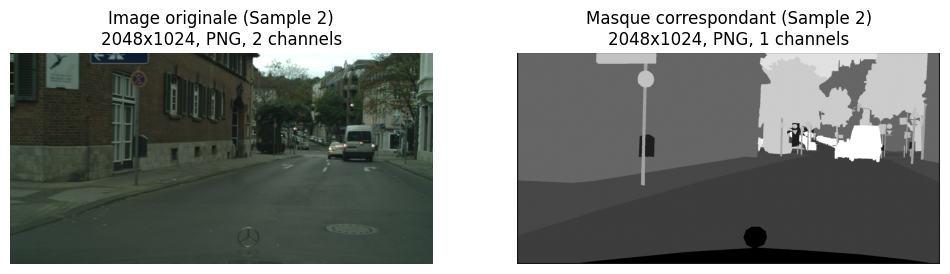

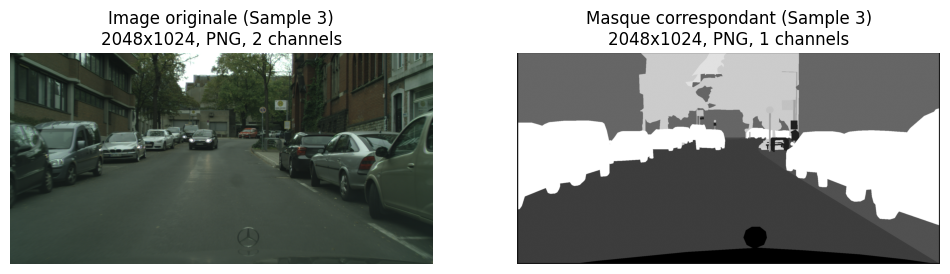

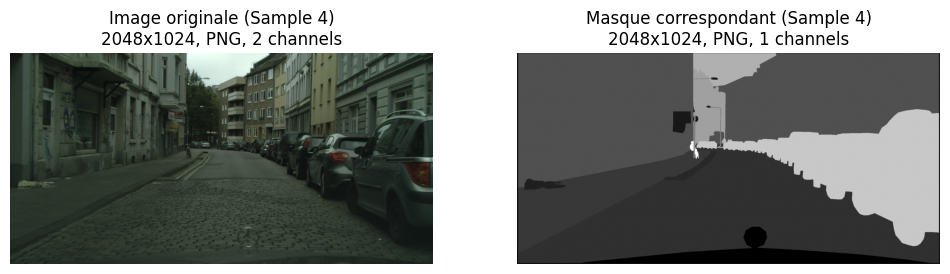

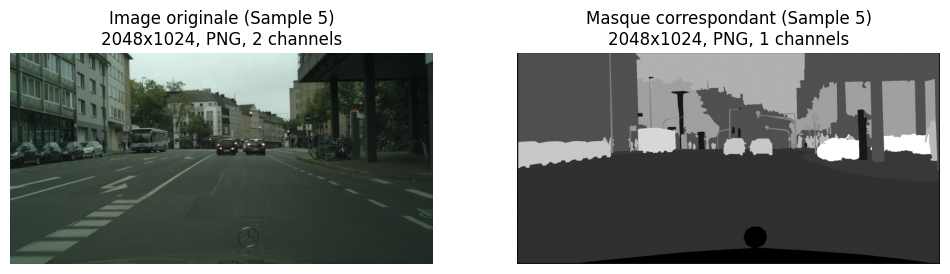

Chemin du masque de test : /content/drive/My Drive/Colab Notebooks/projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine/val/frankfurt/frankfurt_000001_055538_gtFine_labelIds.png
Masque original chargé avec les dimensions: (1024, 2048) et type: uint8
Masque simplifié créé avec les dimensions: (1024, 2048) et type: uint8


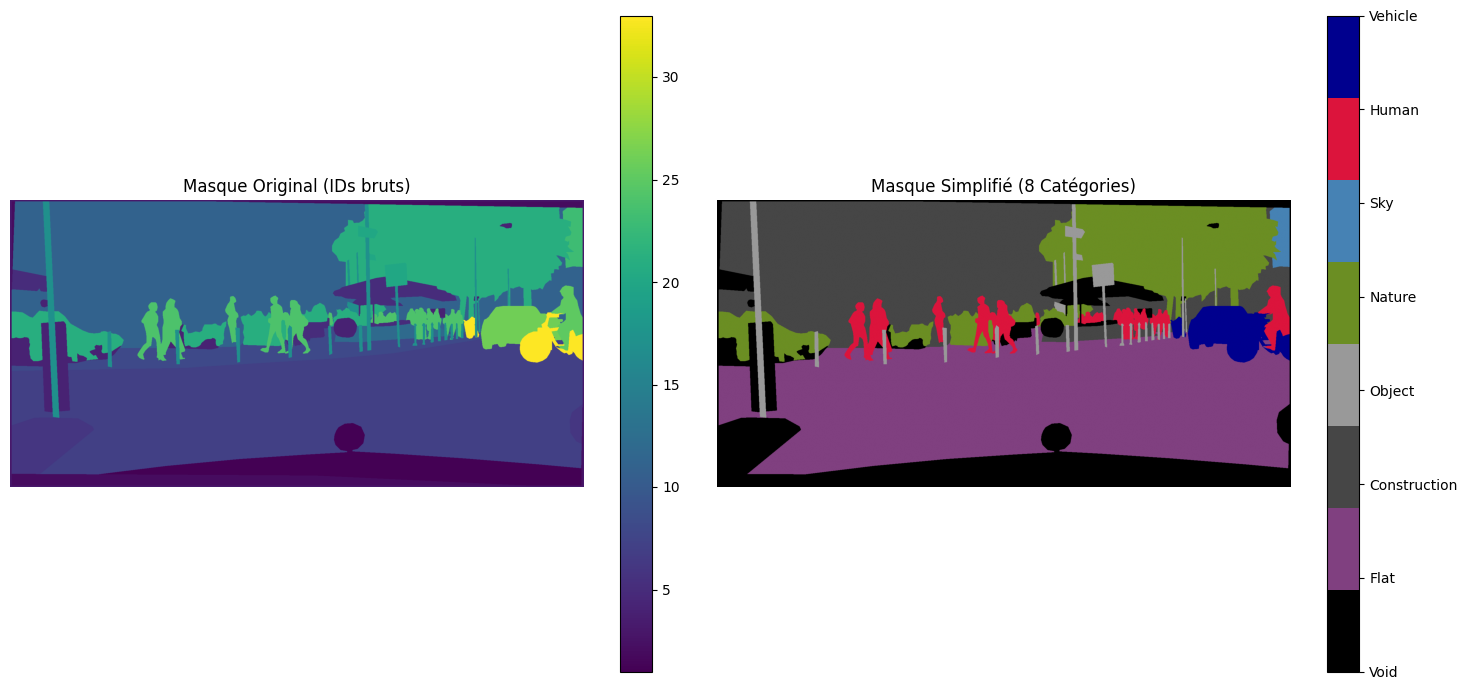

Chemin de l'image d'exemple : /content/drive/My Drive/Colab Notebooks/projet8/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit/val/lindau/lindau_000030_000019_leftImg8bit.png
Chemin du masque d'exemple : /content/drive/My Drive/Colab Notebooks/projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine/val/lindau/lindau_000030_000019_gtFine_labelIds.png
Taille originale image : (1024, 2048, 3)
Taille originale masque : (1024, 2048)
Nouvelle taille image (redimensionnée)  : (256, 256, 3)
Nouvelle taille masque (redimensionné) : (256, 256)


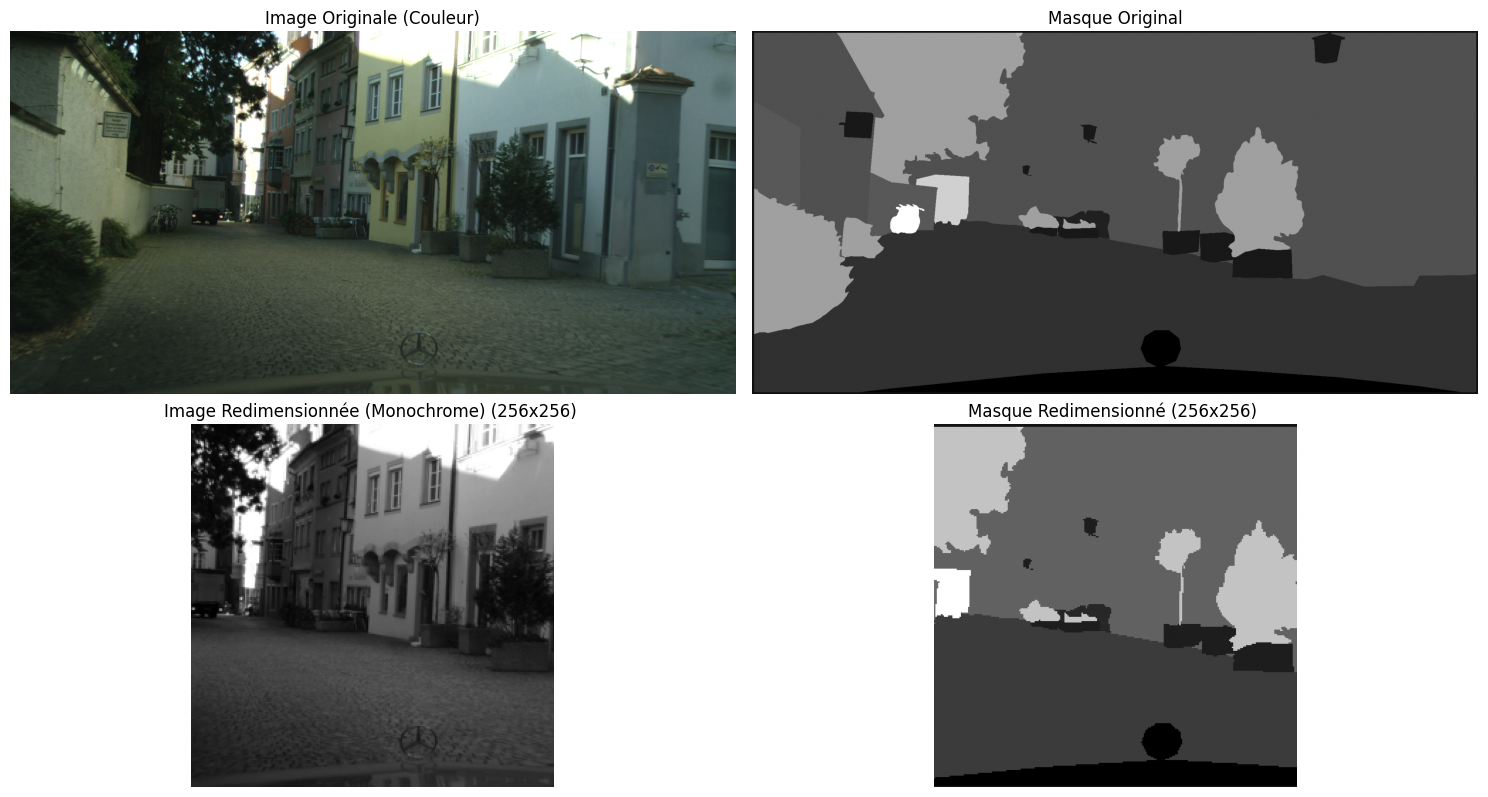

In [ ]:
%run ./p8_1_prepare_image.ipynb

In [ ]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

print("✅ Outils prêts ! On va pouvoir simplifier notre monde.")

✅ Outils prêts ! On va pouvoir simplifier notre monde.


In [ ]:
!pip install segmentation-models-pytorch

import torch
import segmentation_models_pytorch as smp

# 1. Redéfinition de la même architecture de modèle
# Paramètres correspondent à ceux de l'entraînement
model_reconstruit = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1, # Correspond au monochrome utilisé
    classes=8      # Correspond à len(CLASS_NAMES)
)


# 2. Chargez les poids depuis le fichier '.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Chargement des poids du modèle...")
# model_reconstruit.load_state_dict(torch.load("G:\\Mon Drive\\Colab Notebooks\\projet8\\dev\\tuned_model_epochs_3_vs_ref_winner.pth", map_location=device))
model_reconstruit.load_state_dict(torch.load('/content/drive/My Drive/Colab Notebooks/projet8/dev/tuned_model_epochs_5_vs_ref_winner.pth', map_location=device))

# 3. Mettez le modèle en mode évaluation
print("Modèle reconstruit et poids chargés avec succès.")
model_reconstruit.eval()

# Le modèle est maintenant prêt pour l'inférence via API
# (assurez-vous de déplacer le modèle sur le bon périphérique: .to(device))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Chargement des poids du modèle...
Modèle reconstruit et poids chargés avec succès.


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

## Note Technique : API de Segmentation d'Images avec FastAPI

### Introduction

Cette note technique présente une API (Application Programming Interface) développée avec **FastAPI** pour la segmentation sémantique d'images. L'API expose un endpoint unique qui permet aux utilisateurs de soumettre une image, de la faire traiter par un modèle de segmentation **U-Net** pré-entraîné, puis de récupérer le masque de segmentation résultant en format PNG.

### Architecture Technologique

*   **FastAPI** : Framework web moderne, rapide (haute performance) pour construire des APIs avec Python 3.7+ basé sur les types standards Python.
*   **PyTorch** : Bibliothèque open-source de machine learning utilisée pour le modèle de segmentation `model_reconstruit`.
*   **`segmentation_models_pytorch` (smp)** : Librairie qui simplifie l'utilisation de modèles de segmentation populaires, comme U-Net, avec des encodeurs pré-entraînés.
*   **PIL (Pillow)** : Bibliothèque Python pour le traitement d'images, utilisée pour la lecture, la conversion, le redimensionnement et la sauvegarde des images.
*   **Uvicorn** : Serveur ASGI (Asynchronous Server Gateway Interface) haute performance, nécessaire pour exécuter les applications FastAPI de manière asynchrone.

### Endpoint Principal

L'API expose un seul endpoint POST pour la prédiction de masques de segmentation :

*   **`POST /predict_mask`**

    *   **Description** : Cet endpoint accepte un fichier image en entrée, effectue un pré-traitement, applique un modèle de segmentation, puis retourne le masque segmenté coloré sous forme d'image PNG.

    *   **Méthode HTTP** : `POST`

    *   **Paramètres de Requête (Body)** :

        *   `file` : `UploadFile` (Fichier)
            *   **Description** : Le fichier image à segmenter. L'API s'attend à recevoir une image au format courant (JPEG, PNG, etc.).

    *   **Processus Interne** :
        1.  **Pré-traitement de l'image** :
            *   Lecture du contenu du fichier image.
            *   Conversion en niveaux de gris.
            *   Redimensionnement à une taille fixe de `256x256` pixels.
            *   Normalisation des valeurs de pixels (division par 255.0).
            *   Conversion en tenseur PyTorch et ajout des dimensions de batch.
            *   Transfert du tenseur vers le dispositif d'inférence (CPU ou GPU).
        2.  **Inférence du Modèle** :
            *   Le tenseur pré-traité est passé au `model_reconstruit` (un modèle U-Net avec un encodeur ResNet34) pour générer les logits de segmentation.
            *   `torch.no_grad()` est utilisé pour désactiver le calcul des gradients, optimisant ainsi l'inférence.
        3.  **Post-traitement du Masque** :
            *   L'opération `torch.argmax(outputs, dim=1)` est appliquée pour obtenir le masque prédit, où chaque pixel contient l'indice de la classe la plus probable.
            *   Le masque est converti en tableau NumPy sur le CPU.
            *   Le masque NumPy est transformé en une image RVB colorée en utilisant une carte de couleurs (`COLOR_MAP`) prédéfinie, où chaque classe de segmentation est associée à une couleur spécifique.
        4.  **Format de Sortie** :
            *   L'image masquée colorée est encodée au format **PNG** dans un flux binaire en mémoire.

    *   **Réponse HTTP** :

        *   **Type de Contenu** : `image/png`
        *   **Contenu** : Les octets de l'image PNG représentant le masque de segmentation coloré de l'image soumise.

### Déploiement et Exécution

L'application FastAPI peut être exécutée localement en utilisant Uvicorn. Un exemple de commande d'exécution est `uvicorn.run(app, host='0.0.0.0', port=8000)`. Pour un déploiement en production, des serveurs web comme Nginx ou Gunicorn peuvent être utilisés en amont d'Uvicorn.

### Classes et Cartographie des Couleurs

Les classes de segmentation prises en charge par le modèle et leurs couleurs associées sont les suivantes :

| Index | Nom de la Classe | Couleur RVB        |
| :---- | :--------------- | :----------------- |
| 0     | `void` (non étiqueté/hors champ)     | `[0, 0, 0]` (Noir)        |
| 1     | `flat` (surface plane)          | `[81, 0, 81]` (Violet) |
| 2     | `construction` (bâtiments, murs, clôtures)          | `[70, 70, 70] ` (Gris foncé)    |
| 3     | `object` (objets divers, poteaux, feux)         | `[153, 153, 153]` (Gris)  |
| 4     | `nature` (végétation, terrain, ciel)          | `[107, 142, 35]` Vert olive)     |
| 5     | `sky` (ciel)           | `[70, 130, 180]` (Bleu acier)  |
| 6     | `human` (personnes, cavaliers)         | `[220, 20, 60]` (Rouge cramoisi)     |
| 7     | `vehicle` (véhicules motorisés)           | `[0, 0, 142]` (Bleu foncé) |


### Conclusion

Cette API fournit une solution simple et efficace pour intégrer la segmentation d'images basée sur un modèle de deep learning dans d'autres applications. Sa conception avec FastAPI garantit une bonne performance et une facilité d'utilisation grâce à la génération automatique de documentation interactive (Swagger UI/ReDoc).

In [ ]:
import os

%cd /content/drive/My Drive/Colab Notebooks/projet8/dev
!pwd

print("\n✅ Chemin de travail défini et vérifié.")


/content/drive/My Drive/Colab Notebooks/projet8/dev
/content/drive/My Drive/Colab Notebooks/projet8/dev

✅ Chemin de travail défini et vérifié.


In [ ]:
print("Installation des dépendances...")
!pip install segmentation-models-pytorch
print("✅ Dépendances installées.")

Installation des dépendances...
✅ Dépendances installées.


In [ ]:
import torch
import segmentation_models_pytorch as smp

# 1. Redéfinition de la même architecture de modèle
# Les paramètres correspondent à ceux utilisés lors de l'entraînement
model_reconstruit = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1, # Correspond au monochrome utilisé pour l'entrée
    classes=8      # Correspond au nombre de classes de segmentation (len(CLASS_NAMES))
)


# 2. Chargez les poids depuis le fichier '.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Chargement des poids du modèle...")
model_reconstruit.load_state_dict(torch.load('/content/drive/My Drive/Colab Notebooks/projet8/dev/tuned_model_epochs_5_vs_ref_winner.pth', map_location=device))

# 3. Mettez le modèle en mode évaluation
print("Modèle reconstruit et poids chargés avec succès.")
model_reconstruit.eval()

# Le modèle est maintenant prêt pour l'inférence (assurez-vous de le déplacer sur le bon périphérique: .to(device))

Chargement des poids du modèle...
Modèle reconstruit et poids chargés avec succès.


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

# Définition de l'API FastAPI
Définir un endpoint POST `/predict_mask` dans FastAPI qui accepte une image, la pré-traite avec `preprocess_image`, effectue l'inférence avec `model_reconstruit` et génère le masque prédit.

In [4]:
%cd /content/drive/MyDrive/Colab Notebooks/projet8/dev/heroku-fastapi

/content/drive/MyDrive/Colab Notebooks/projet8/dev/heroku-fastapi


In [ ]:
%%shell
cp ../tuned_model_epochs_3_vs_ref_winner.pth .

In [ ]:
%%writefile segmentit_fastapi.py
import os
from fastapi import FastAPI, UploadFile, File, Response
from PIL import Image
import io
import numpy as np
import torch
import segmentation_models_pytorch as smp

# 1. Instanciation de l'application FastAPI
app = FastAPI()

# 2. Définition du périphérique pour les opérations PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 3. Redefinition de la même architecture de modèle
# Paramètres correspondent à ceux de l'entraînement
model_reconstruit = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1, # Correspond au monochrome utilisé
    classes=8      # Correspond à len(CLASS_NAMES)
)

# 4. Chargez les poids depuis le fichier '.pth'
# Assurez-vous que ce chemin est correct pour le déploiement Docker
model_path = os.path.join("/app", "tuned_model_epochs_5_vs_ref_winner.pth") # Adjust path for Docker
print(f"Loading model weights from: {model_path}")
model_reconstruit.load_state_dict(torch.load(model_path, map_location=device))
model_reconstruit.eval()

# 5. Move the model to the defined device
model_reconstruit.to(device);
print("✅ Model moved to device.")

# 6. Define CLASS_NAMES and COLOR_MAP for Cityscapes main classes
CLASS_NAMES = [
    'void',
    'flat',
    'construction',
    'object',
    'nature',
    'sky',
    'human',
    'vehicle'
]
COLOR_MAP = [
    [0, 0, 0],          # 0. void (Noir)
    [81, 0, 81],        # 1. flat (Violet)
    [70, 70, 70],       # 2. construction (Gris foncé)
    [153, 153, 153],    # 3. object (Gris)
    [107, 142, 35],     # 4. nature (Vert olive)
    [70, 130, 180],     # 5. sky (Bleu acier)
    [220, 20, 60],      # 6. human (Rouge cramoisi)
    [0, 0, 142]         # 7. vehicle (Bleu foncé)
]

IMG_SIZE = (256, 256)

async def preprocess_image(image_file: UploadFile):
    # 3. Lire le contenu du fichier UploadFile de manière asynchrone
    contents = await image_file.read()

    # 4. Ouvrir le contenu de l'image en utilisant PIL.Image.open
    image = Image.open(io.BytesIO(contents))

    # 5. Convertir l'image en niveaux de gris
    image = image.convert('L')

    # 6. Redimensionner l'image en niveaux de gris à IMG_SIZE
    image = image.resize(IMG_SIZE, Image.Resampling.LANCZOS)

    # 7. Convertir l'image PIL traitée en un tableau NumPy
    image_np = np.array(image)

    # 8. Normaliser les valeurs de pixels du tableau NumPy en divisant par 255.0
    image_np = image_np / 255.0

    # 9. Convertir le tableau NumPy normalisé en un tenseur PyTorch de type torch.float32
    image_tensor = torch.from_numpy(image_np).float()

    # 10. Remodeler le tenseur pour ajouter une dimension de canal et une dimension de batch
    image_tensor = image_tensor.unsqueeze(0).unsqueeze(0) # (1, 1, H, W)

    # 11. Déplacer le tenseur préparé vers le périphérique (CPU ou GPU)
    image_tensor = image_tensor.to(device)

    # 12. Retourner le tenseur PyTorch pré-traité
    return image_tensor

@app.post("/predict_mask")
async def predict_mask(file: UploadFile = File(...)):
    # Pré-traitement de l'image entrante
    preprocessed_image = await preprocess_image(file)

    # Exécution de l'inférence avec le modèle reconstruit
    with torch.no_grad():
        outputs = model_reconstruit(preprocessed_image)

    # Obtention du masque prédit en appliquant argmax pour chaque pixel
    # Les 'outputs' ont la forme (batch_size, num_classes, H, W).
    # argmax(dim=1) retourne les indices de classe les plus probables pour chaque pixel (batch_size, H, W).
    predicted_mask_tensor = torch.argmax(outputs, dim=1)

    # Déplacement du masque prédit vers le CPU et conversion en tableau NumPy
    predicted_mask_np = predicted_mask_tensor.cpu().numpy()

    # Extraction de la première (et unique) image du lot
    predicted_mask_single_image = predicted_mask_np[0]

    # Transformation du masque NumPy en une image RVB colorée en utilisant la carte de couleurs (COLOR_MAP).
    # Chaque classe de segmentation est associée à une couleur spécifique pour une meilleure visualisation.
    colored_mask = np.zeros((*predicted_mask_single_image.shape, 3), dtype=np.uint8)
    for class_idx, color in enumerate(COLOR_MAP):
        colored_mask[predicted_mask_single_image == class_idx] = color
    mask_pil_image = Image.fromarray(colored_mask, mode='RGB')

    # Conversion de l'image PIL colorée en un flux binaire PNG en mémoire
    img_byte_arr = io.BytesIO()
    mask_pil_image.save(img_byte_arr, format='PNG')
    img_byte_arr = img_byte_arr.getvalue()

    # Retourne l'image PNG résultante en tant que réponse HTTP
    return Response(content=img_byte_arr, media_type="image/png")


Writing segmentit_fastapi.py


## Synthèse de la configuration de l'API

### Résultats Clés
Le point d'accès `POST /predict_mask` a été implémenté avec succès, permettant la segmentation d'images via FastAPI. Les étapes clés réalisées sont :
1.  **Définition de l'Endpoint** : Un point d'accès asynchrone `POST /predict_mask` acceptant un `UploadFile` (l'image à segmenter) a été créé.
2.  **Pré-traitement de l'Image** : Une fonction `preprocess_image` a été intégrée pour préparer l'image entrante au format attendu par le modèle de segmentation (conversion en niveaux de gris, redimensionnement à 256x256, normalisation, et conversion en tenseur PyTorch).
3.  **Inférence du Modèle** : Le modèle `model_reconstruit` a été utilisé pour générer le masque de segmentation, avec `torch.no_grad()` pour optimiser l'inférence.
4.  **Post-traitement du Masque** : Le masque prédit (initialement un tenseur PyTorch) est converti en tableau NumPy, puis transformé en une image RVB colorée grâce à une `COLOR_MAP` prédéfinie pour une visualisation claire des différentes classes de segmentation.
5.  **Format de Sortie** : L'image masquée colorée est encodée au format PNG dans un flux binaire en mémoire et retournée comme réponse HTTP avec le `media_type` approprié (`image/png`).

### Prochaines Étapes et Optimisations
*   **Enrichissement de la Réponse** : Pour des applications plus avancées, il serait pertinent de fournir des informations additionnelles dans la réponse, telles que les probabilités de classe ou des métadonnées sur la segmentation, potentiellement sous forme d'objet JSON incluant l'image encodée (par exemple, en Base64).
*   **Optimisation des Performances** : Évaluer l'impact des conversions d'images (NumPy vers PIL, puis vers bytes) sur la latence de l'API. Des optimisations ou l'exploration de formats alternatifs pourraient être envisagées si le temps de réponse devient critique pour des charges importantes.

## Synthèse de la Préparation au Déploiement

### Résultats Clés
La configuration de l'application pour le déploiement sur Heroku a été finalisée avec succès :
*   **`requirements.txt`** : Un fichier a été généré, listant toutes les dépendances Python nécessaires (`fastapi`, `uvicorn`, `segmentation-models-pytorch`, `torch`, `torchvision`, `Pillow`, `numpy`, `python-multipart`).
*   **`Dockerfile`** : Un Dockerfile robuste a été créé, utilisant une image de base `python:3.9-slim-buster`, configurant l'environnement de travail, copiant les dépendances et le code de l'application (y compris le modèle entraîné `tuned_model_epochs_3_vs_ref_winner.pth`), exposant le port 8000, et définissant la commande de démarrage Uvicorn (`uvicorn segmentit_fastapi:app --host 0.0.0.0 --port 8000`).
*   **`Procfile`** : Un Procfile a été mis en place pour Heroku, spécifiant la commande de démarrage web (`web: uvicorn segmentit_fastapi:app --host 0.0.0.0 --port $PORT`), garantissant que Uvicorn écoute sur le port dynamiquement assigné par Heroku.
*   **Adaptation de l'Application FastAPI** : Le code principal de l'application FastAPI a été ajusté en supprimant l'appel direct à `uvicorn.run()`, permettant ainsi aux plateformes de déploiement externes comme Heroku de gérer le démarrage de l'application via le Procfile. L'objet `app` est globalement accessible, ce qui assure une bonne intégration avec Uvicorn.

### Prochaines Étapes
L'application est désormais entièrement configurée avec tous les fichiers d'environnement essentiels (`requirements.txt`, `Dockerfile`, `Procfile`) pour la conteneurisation et le déploiement sur des plateformes telles que Heroku.
La prochaine étape consiste à :
1.  Construire et pousser l'image Docker vers le Container Registry d'Heroku.
2.  Libérer l'image poussée pour déployer l'application, rendant l'API accessible.
3.  Procéder à des tests exhaustifs de l'API déployée, y compris l'envoi d'images de test et la vérification des masques de segmentation retournés.

## Synthèse de la Préparation au Déploiement

### Résultats Clés
La configuration de l'application pour le déploiement sur Heroku a été finalisée avec succès :
*   **`requirements.txt`** : Un fichier a été généré, listant toutes les dépendances Python nécessaires (`fastapi`, `uvicorn`, `segmentation-models-pytorch`, `torch`, `torchvision`, `Pillow`, `numpy`, `python-multipart`).
*   **`Dockerfile`** : Un Dockerfile robuste a été créé, utilisant une image de base `python:3.9-slim-buster`, configurant l'environnement de travail, copiant les dépendances et le code de l'application (y compris le modèle entraîné `tuned_model_epochs_3_vs_ref_winner.pth`), exposant le port 8000, et définissant la commande de démarrage Uvicorn (`uvicorn segmentit_fastapi:app --host 0.0.0.0 --port 8000`).
*   **`Procfile`** : Un Procfile a été mis en place pour Heroku, spécifiant la commande de démarrage web (`web: uvicorn segmentit_fastapi:app --host 0.0.0.0 --port $PORT`), garantissant que Uvicorn écoute sur le port dynamiquement assigné par Heroku.
*   **Adaptation de l'Application FastAPI** : Le code principal de l'application FastAPI a été ajusté en supprimant l'appel direct à `uvicorn.run()`, permettant ainsi aux plateformes de déploiement externes comme Heroku de gérer le démarrage de l'application via le Procfile. L'objet `app` est globalement accessible, ce qui assure une bonne intégration avec Uvicorn.

### Prochaines Étapes
L'application est désormais entièrement configurée avec tous les fichiers d'environnement essentiels (`requirements.txt`, `Dockerfile`, `Procfile`) pour la conteneurisation et le déploiement sur des plateformes telles que Heroku.
La prochaine étape consiste à :
1.  Construire et pousser l'image Docker vers le Container Registry d'Heroku.
2.  Libérer l'image poussée pour déployer l'application, rendant l'API accessible.
3.  Procéder à des tests exhaustifs de l'API déployée, y compris l'envoi d'images de test et la vérification des masques de segmentation retournés.


## Définition des dépendances dans `requirements.txt`



In [ ]:
%%writefile requirements.txt
fastapi
uvicorn
segmentation-models-pytorch
torch
torchvision
Pillow
numpy
python-multipart

print("✅ 'requirements.txt' créé avec les dépendances spécifiées.")

Overwriting requirements.txt


## Création du fichier `Dockerfile`



In [1]:
%%writefile Dockerfile
# Utiliser une image de base Python légère
FROM python:3.9-slim-buster

# Définir le répertoire de travail à l'intérieur du conteneur
WORKDIR /app

# Copier le fichier des dépendances et installer les dépendances
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copier le code de l'application et le modèle entraîné
COPY segmentit_fastapi.py .
# Correction : Utilisation du modèle V5 pour correspondre au code de l'API
COPY tuned_model_epochs_5_vs_ref_winner.pth .

# Exposer le port sur lequel Uvicorn s'exécutera
EXPOSE 8000

# Commande pour exécuter l'application FastAPI avec Uvicorn
CMD ["uvicorn", "segmentit_fastapi:app", "--host", "0.0.0.0", "--port", "8000"]

Writing Dockerfile


## Création du fichier `Procfile`

---





In [ ]:
%%writefile Procfile
web: uvicorn segmentit_fastapi:app --host 0.0.0.0 --port $PORT

Overwriting Procfile


### Optimisation : Exportation vers le format ONNX

Pour améliorer les performances d'inférence (latence réduite) lors du déploiement sur Heroku, nous pouvons convertir le modèle PyTorch (`.pth`) au format standard **ONNX**.

#### 1. Exécution du script d'export
Utilisez le script dédié pour générer le fichier `model.onnx` :

```bash
python "/content/drive/MyDrive/Colab Notebooks/projet8/dev/heroku-fastapi/export_onnx.py"
```

#### 2. Mise à jour de l'API (`segmentit_fastapi.py`)
Dans le code FastAPI, on remplace le chargement PyTorch par le runtime ONNX :

```python
import onnxruntime as ort

# Chargement de la session ONNX
ort_session = ort.InferenceSession("model.onnx")

def predict(image_tensor):
    inputs = {ort_session.get_inputs()[0].name: image_tensor.numpy()}
    outputs = ort_session.run(None, inputs)
    return outputs
```

#### 3. Déploiement sur Heroku avec ONNX
1. **Dépendances** : Ajouter `onnxruntime` dans le fichier `requirements.txt`.
2. **Dockerfile** : Modifier la ligne `COPY` pour inclure le fichier `.onnx` au lieu du `.pth`.
3. **Build & Push** :
   ```bash
   heroku container:push web --app segmentit
   heroku container:release web --app segmentit
   ```

# Tâches de déploiement et de suivi de déploiement sous Heroku


Voici les étapes pour déployer votre application Docker sur Heroku via la CLI :

1. Se connecter à Heroku:
```bash
heroku login
```

2. Se Connecter au Container Registry d'Heroku:
```bash
heroku container:login
```

3. Créer une nouvelle application Heroku :
```bash
heroku create segmenit
```

4. S'assurer d'être dans le bon répertoire (où se trouvent Dockerfile, Procfile, requirements.txt, et segmentit_fastapi.py):
```bash
# Si vous n'êtes pas déjà dedans, naviguez vers le répertoire heroku-fastapi
cd heroku-fastapi

heroku stack:set container --app segmentit

```


5. Build et push l'image Docker vers le Container Registry d'Heroku:
```bash
heroku container:push web --app segmentit
```

6. Relâcher l'image poussée pour déployer l'application:
```bash
heroku container:release web --app segmentit
```

7. (Optionnel) Ouvrir l'application dans le navigateur:
```bash
heroku open --app segmentit
```

8. (Optionnel) Vérifier les logs en cas de problème
```bash
heroku logs --tail --app segmentit
```

## Comment exécuter la Requête Postman

### Objectif:
Fournir des instructions détaillées sur la façon de configurer une requête POST dans Postman. Cela inclut la définition de la méthode, de l'URL, la configuration du 'Body' en tant que 'form-data', la spécification de la clé comme 'file', la modification de son type en 'File', et la sélection d'un fichier image à télécharger.

#### Instructions
1. Ouvrir l'application Postman.
2. Cliquer sur le bouton '+' pour créer une nouvelle requête HTTP.
3. Définir la méthode HTTP sur `POST` à partir du menu déroulant.
4. Dans le champ URL, entrer le point d'accès de l'API de l'application Heroku déployée: `https://segmenit-bc9eca3bda79.herokuapp.com/predict_mask`.
5. Naviguer vers l'onglet 'Body' sous le champ URL.
6. Sélectionner le bouton radio 'form-data'.
7. Dans l'éditeur clé-valeur, dans la colonne 'Key', entrer `file`.
8. À côté du champ 'Key', il y a un menu déroulant qui est par défaut sur 'Text'. Le changer en 'File'.
9. Un bouton 'Select Files' apparaîtra dans la colonne 'Value'. Cliquer sur ce bouton et choisir un fichier image (par exemple, un fichier `.png` ou `.jpg`) depuis la machine locale à télécharger.
10. Cliquer sur le bouton 'Send' pour exécuter la requête. La réponse de l'API (l'image segmentée) apparaîtra dans la section de réponse.

### Méthode 1: Utilisation de `curl` (depuis le terminal ou un `%%bash` en Colab)

Utiliser `curl` pour envoyer une requête POST avec votre fichier image. S'assurer que l'image `test_image.png` est dans le répertoire courant ou spécifier le chemin complet.

In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks/projet8/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit/val/frankfurt"

/content/drive/MyDrive/Colab Notebooks/projet8/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit/val/frankfurt


In [ ]:
%%bash
API_URL="https://segmenit-bc9eca3bda79.herokuapp.com/predict_mask"
TEST_IMAGE="test_image.png"
OUTPUT_MASK="predicted_mask_curl.png"

# Envoyer la requête et enregistrer le masque résultant
curl -X POST -F "file=@$TEST_IMAGE" $API_URL --output $OUTPUT_MASK

echo "Masque prédit enregistré sous $OUTPUT_MASK"


Masque prédit enregistré sous predicted_mask_curl.png


curl: (26) Failed to open/read local data from file/application


### Méthode 2: Utilisation de Python avec la bibliothèque `requests`

C'est la méthode la plus courante pour intégrer l'API dans une autre application Python.

Envoi de l'image 'frankfurt_000000_003357_leftImg8bit.png' à l'API...
Requête réussie ! Sauvegarde du masque...
Masque prédit enregistré sous 'predicted_mask_python.png'


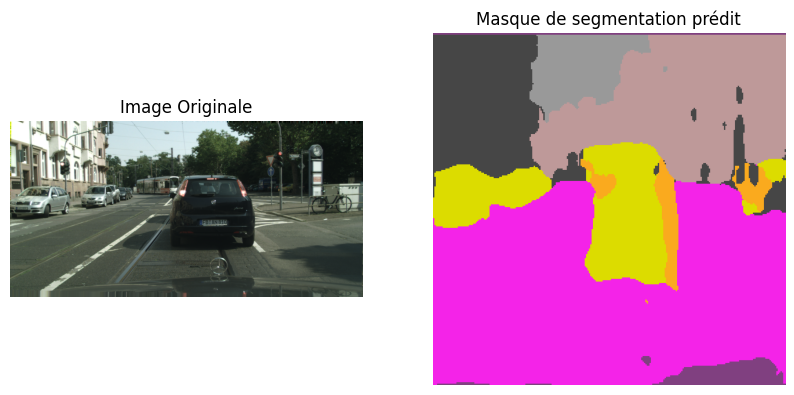

In [ ]:
import requests
import io
from PIL import Image
import matplotlib.pyplot as plt

API_URL = "https://segmenit-bc9eca3bda79.herokuapp.com/predict_mask"
TEST_IMAGE = "frankfurt_000000_003357_leftImg8bit.png"
OUTPUT_MASK_PYTHON = "predicted_mask_python.png"

# Ouvrir l'image de test en mode binaire
with open(TEST_IMAGE, 'rb') as f:
    files = {'file': (TEST_IMAGE, f, 'image/png')}

    print(f"Envoi de l'image '{TEST_IMAGE}' à l'API...")
    response = requests.post(API_URL, files=files)

# Vérifier la réponse
if response.status_code == 200:
    print("Requête réussie ! Sauvegarde du masque...")
    # Le contenu de la réponse est directement l'image PNG du masque
    with open(OUTPUT_MASK_PYTHON, 'wb') as f_out:
        f_out.write(response.content)
    print(f"Masque prédit enregistré sous '{OUTPUT_MASK_PYTHON}'")

    # Afficher l'image originale
    try:
        original_image = Image.open(TEST_IMAGE)
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original_image)
        plt.title("Image Originale")
        plt.axis('off')

        # Afficher le masque prédit
        mask_image = Image.open(io.BytesIO(response.content))
        plt.subplot(1, 2, 2)
        plt.imshow(mask_image)
        plt.title("Masque de segmentation prédit")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Erreur lors de l'affichage des images: {e}")

else:
    print(f"Erreur lors de la requête: {response.status_code}")
    print(f"Message d'erreur: {response.text}")

# 🏁 Conclusion et Perspectives

### Réalisations Clés
- **Modèle Performant** : Utilisation d'un U-Net avec encodeur ResNet34 pré-entraîné, optimisé sur 5 époques pour la segmentation de Cityscapes.
- **Architecture API** : Mise en place d'une interface robuste avec **FastAPI**, permettant une inférence asynchrone performante.
- **Prêt pour la Production** : Conteneurisation complète via **Docker**, facilitant le déploiement sur n'importe quel service Cloud (Heroku, AWS, etc.).
- **Post-traitement Visuel** : Conversion automatique des masques de classes en images colorées pour une interprétation métier immédiate.

### Améliorations Possibles (Perspectives)
- **Optimisation** : Conversion du modèle en format ONNX ou TensorRT pour réduire encore la latence d'inférence.
- **Monitoring** : Intégration de Prometheus/Grafana pour suivre les performances de l'API en temps réel.
- **Interface Utilisateur** : Développement d'un frontend plus élaboré (Streamlit ou React) pour une démonstration interactive.

